# Seismic Data Visualization

0. Study area and earthquake catalog  
1. Raw seismic data for a random day  
2. Effect of preprocessing (normalize → detrend linear → demean)  
3. Earthquake vs Noise 20-second windows  
4. Data augmentation — individual filters and increasing intensity

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from obspy import read

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

In [2]:
BASE_DIR      = r"D:\Conv_NN\data" 
SEISMIC_DIR   = os.path.join(BASE_DIR, 'raw', 'mseed')
EQ_DIR        = os.path.join(BASE_DIR, 'processed', 'windows','train', 'earthquake')
NOISE_DIR     = os.path.join(BASE_DIR, 'processed', 'windows','train', 'noise')
SAMPLING_RATE = 100.0  # Hz

def ensure_2d(arr):
    """Guarantee shape (n_channels, n_samples) even for single-channel CSVs."""
    return arr[np.newaxis, :] if arr.ndim == 1 else arr

# ---- augmentation helper used only for visualisation ----

def gauss(data, sigma):
    return np.clip(data + np.random.normal(0, sigma, data.shape), -1.0, 1.0)

# ---- shared plot helper ----

def plot_progression(rows_data, row_labels, ch_labels, title, colors=None):
    """Grid plot: rows = original + augmented variants, columns = channels."""
    n_rows = len(rows_data)
    n_ch   = rows_data[0].shape[0]
    t      = np.arange(rows_data[0].shape[1]) / SAMPLING_RATE
    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 0.9, n_rows))

    fig, axes = plt.subplots(n_rows, n_ch,
                             figsize=(5 * n_ch, 2.2 * n_rows),
                             sharex=True)
    if n_rows == 1: axes = axes[np.newaxis, :]
    if n_ch  == 1: axes = axes[:, np.newaxis]

    for r, (data, label, color) in enumerate(zip(rows_data, row_labels, colors)):
        for c in range(n_ch):
            axes[r, c].plot(t, data[c], lw=0.8, color=color)
            axes[r, c].grid(alpha=0.3)
            if r == 0:
                axes[r, c].set_title(ch_labels[c], fontweight='bold')
            if c == n_ch - 1:
                axes[r, c].set_ylabel(label, fontsize=8, fontweight='bold',
                                      color=color, rotation=0,
                                      labelpad=5, ha='left', va='center')
                axes[r, c].yaxis.set_label_position('right')
            if r == n_rows - 1:
                axes[r, c].set_xlabel('Time (s)')

    fig.suptitle(title, fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.show()

## 0 — Study area and earthquake catalog

OGS earthquake locations (Feb 2014 – Feb 2015) within the study area (35.7–36.0°N, 97.2–97.6°W), and the OK027 seismic station used for data download.

Earthquake events: 1285
            origintime  latitude  longitude  depth_km
0  2014-02-15 00:19:13  35.78179  -97.48073     5.000
1  2014-02-15 00:39:19  35.88586  -97.30073     5.137
2  2014-02-15 01:15:47  35.77693  -97.47593     5.000
3  2014-02-15 02:05:54  35.78040  -97.48116     5.000
4  2014-02-15 05:51:11  35.78011  -97.47118     5.000


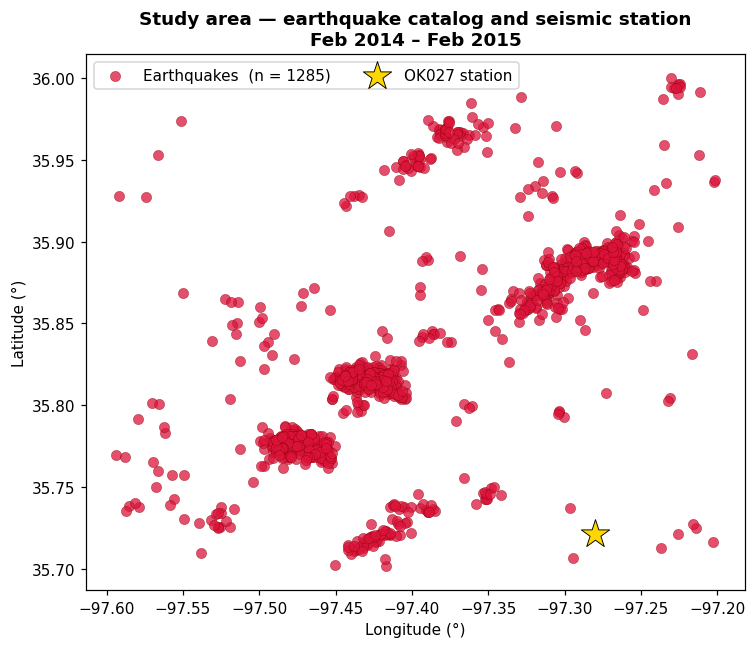

In [3]:
import pandas as pd

CATALOG_CSV = os.path.join(BASE_DIR, 'interim', 'historical_corrected.csv')
STATION_LAT = 35.721   # OK027
STATION_LON = -97.28

catalog = pd.read_csv(CATALOG_CSV, parse_dates=['corrected_time'])
print(f'Earthquake events: {len(catalog)}')
print(catalog[['origintime', 'latitude', 'longitude', 'depth_km']].head())

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    catalog['longitude'], catalog['latitude'],
    c='crimson', s=45, alpha=0.75, edgecolors='darkred', linewidths=0.3,
    zorder=3, label=f'Earthquakes  (n = {len(catalog)})'
)
ax.scatter(
    STATION_LON, STATION_LAT,
    marker='*', s=380, c='gold', edgecolors='black', linewidths=0.6,
    zorder=4, label='OK027 station'
)

ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.set_title('Study area — earthquake catalog and seismic station\n'
             'Feb 2014 – Feb 2015', fontweight='bold')
ax.legend(loc='upper left', ncols=2)
plt.tight_layout()
plt.show()

### 0b — K-means clustering of earthquake locations

K-means is applied to the (longitude, latitude) coordinates for k = 2–8.  
The best k is chosen by maximising the **silhouette score** (measures how well each point fits its own cluster vs. the nearest neighbouring cluster; ranges from −1 to 1, higher is better).  
The elbow plot is shown alongside as a secondary reference.

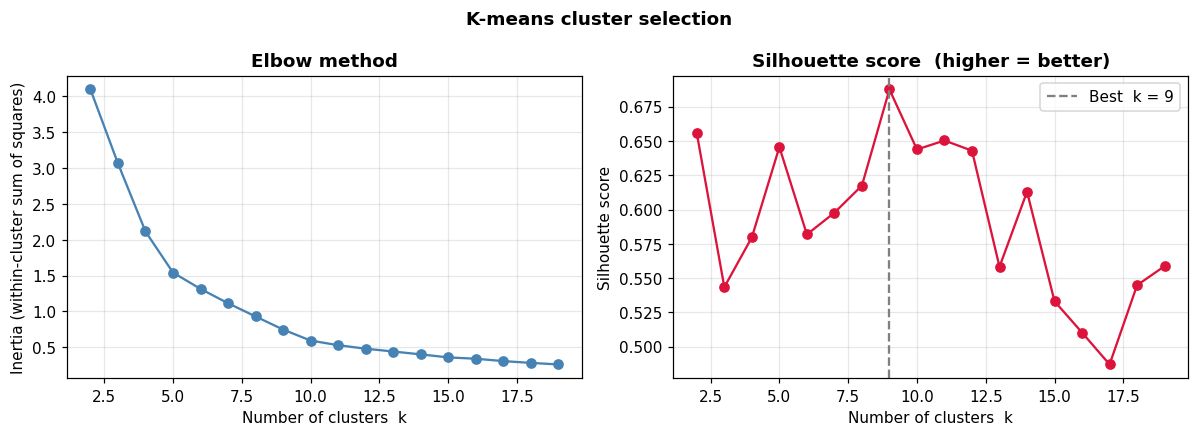

Best k by silhouette score: 9


In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

coords = catalog[['longitude', 'latitude']].values

k_range    = range(2, 20)
inertias   = []
sil_scores = []

for k in k_range:
    km  = KMeans(n_clusters=k, random_state=420, n_init=10)
    lbl = km.fit_predict(coords)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(coords, lbl))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(list(k_range), inertias, 'o-', color='steelblue', lw=1.5)
axes[0].set_xlabel('Number of clusters  k')
axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
axes[0].set_title('Elbow method', fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_range), sil_scores, 'o-', color='crimson', lw=1.5)
axes[1].set_xlabel('Number of clusters  k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score  (higher = better)', fontweight='bold')
axes[1].grid(alpha=0.3)

best_k = list(k_range)[int(np.argmax(sil_scores))]
axes[1].axvline(best_k, linestyle='--', color='gray', label=f'Best  k = {best_k}')
axes[1].legend()

plt.suptitle('K-means cluster selection', fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Best k by silhouette score: {best_k}')

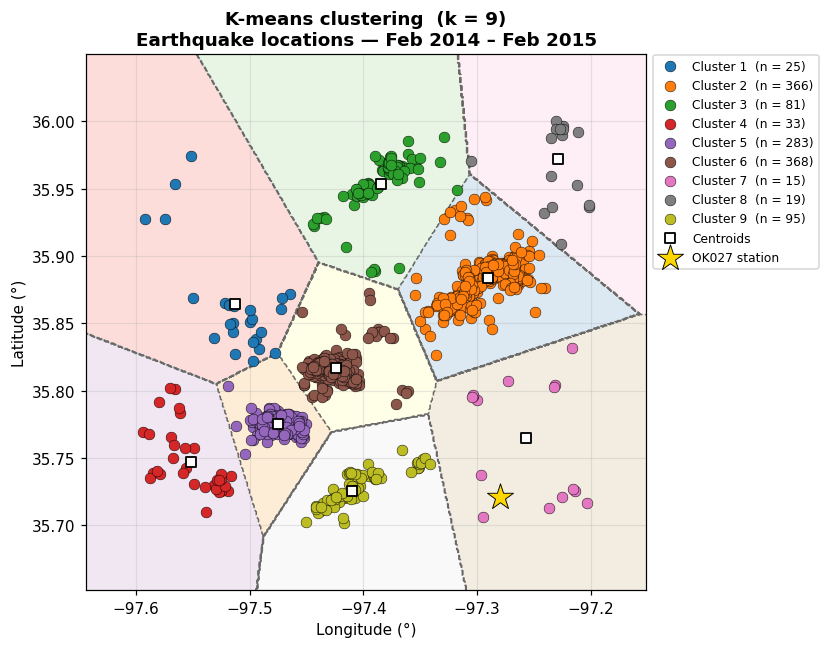

In [5]:
km_best = KMeans(n_clusters=best_k, random_state=420, n_init=10)
labels  = km_best.fit_predict(coords)
centers = km_best.cluster_centers_

# Decision-region background via meshgrid
pad    = 0.05
lon_g  = np.linspace(coords[:, 0].min() - pad, coords[:, 0].max() + pad, 500)
lat_g  = np.linspace(coords[:, 1].min() - pad, coords[:, 1].max() + pad, 500)
xx, yy = np.meshgrid(lon_g, lat_g)
zz     = km_best.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))

ax.contourf(xx, yy, zz,
            levels=np.arange(-0.5, best_k + 0.5),
            cmap='Pastel1', alpha=0.45, zorder=1)
ax.contour(xx, yy, zz,
           levels=np.arange(-0.5, best_k + 0.5),
           colors='dimgray', linewidths=1.0, linestyles='--', zorder=2)

tab_colors = plt.cm.tab10.colors
for k in range(best_k):
    mask = labels == k
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=[tab_colors[k]], s=50, edgecolors='k', linewidths=0.3,
               zorder=3, label=f'Cluster {k + 1}  (n = {int(mask.sum())})')

ax.scatter(centers[:, 0], centers[:, 1],
           marker='s', s=50, c='white', edgecolors='black', linewidths=1.2,
           zorder=4, label='Centroids')
ax.scatter(STATION_LON, STATION_LAT,
           marker='*', s=320, c='gold', edgecolors='black', linewidths=0.6,
           zorder=5, label='OK027 station')

ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.set_title(f'K-means clustering  (k = {best_k})\n'
             'Earthquake locations — Feb 2014 – Feb 2015', fontweight='bold')
ax.legend(fontsize=8, loc='upper right', bbox_to_anchor=(1.32, 1.01))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 1 — Raw seismic data for a random day

File: OK027_2014-03-09.mseed
6 Trace(s) in Stream:
GS.OK027.00.HH1 | 2014-03-09T00:00:00.000000Z - 2014-03-09T09:01:37.890000Z | 100.0 Hz, 3249790 samples
GS.OK027.00.HH1 | 2014-03-09T13:19:48.480000Z - 2014-03-09T23:59:59.000000Z | 100.0 Hz, 3841053 samples
GS.OK027.00.HH2 | 2014-03-09T00:00:00.000000Z - 2014-03-09T09:01:37.830000Z | 100.0 Hz, 3249784 samples
GS.OK027.00.HH2 | 2014-03-09T13:19:46.860000Z - 2014-03-09T23:59:59.000000Z | 100.0 Hz, 3841215 samples
GS.OK027.00.HHZ | 2014-03-09T00:00:00.000000Z - 2014-03-09T09:01:35.670000Z | 100.0 Hz, 3249568 samples
GS.OK027.00.HHZ | 2014-03-09T13:19:47.800000Z - 2014-03-09T23:59:59.000000Z | 100.0 Hz, 3841121 samples


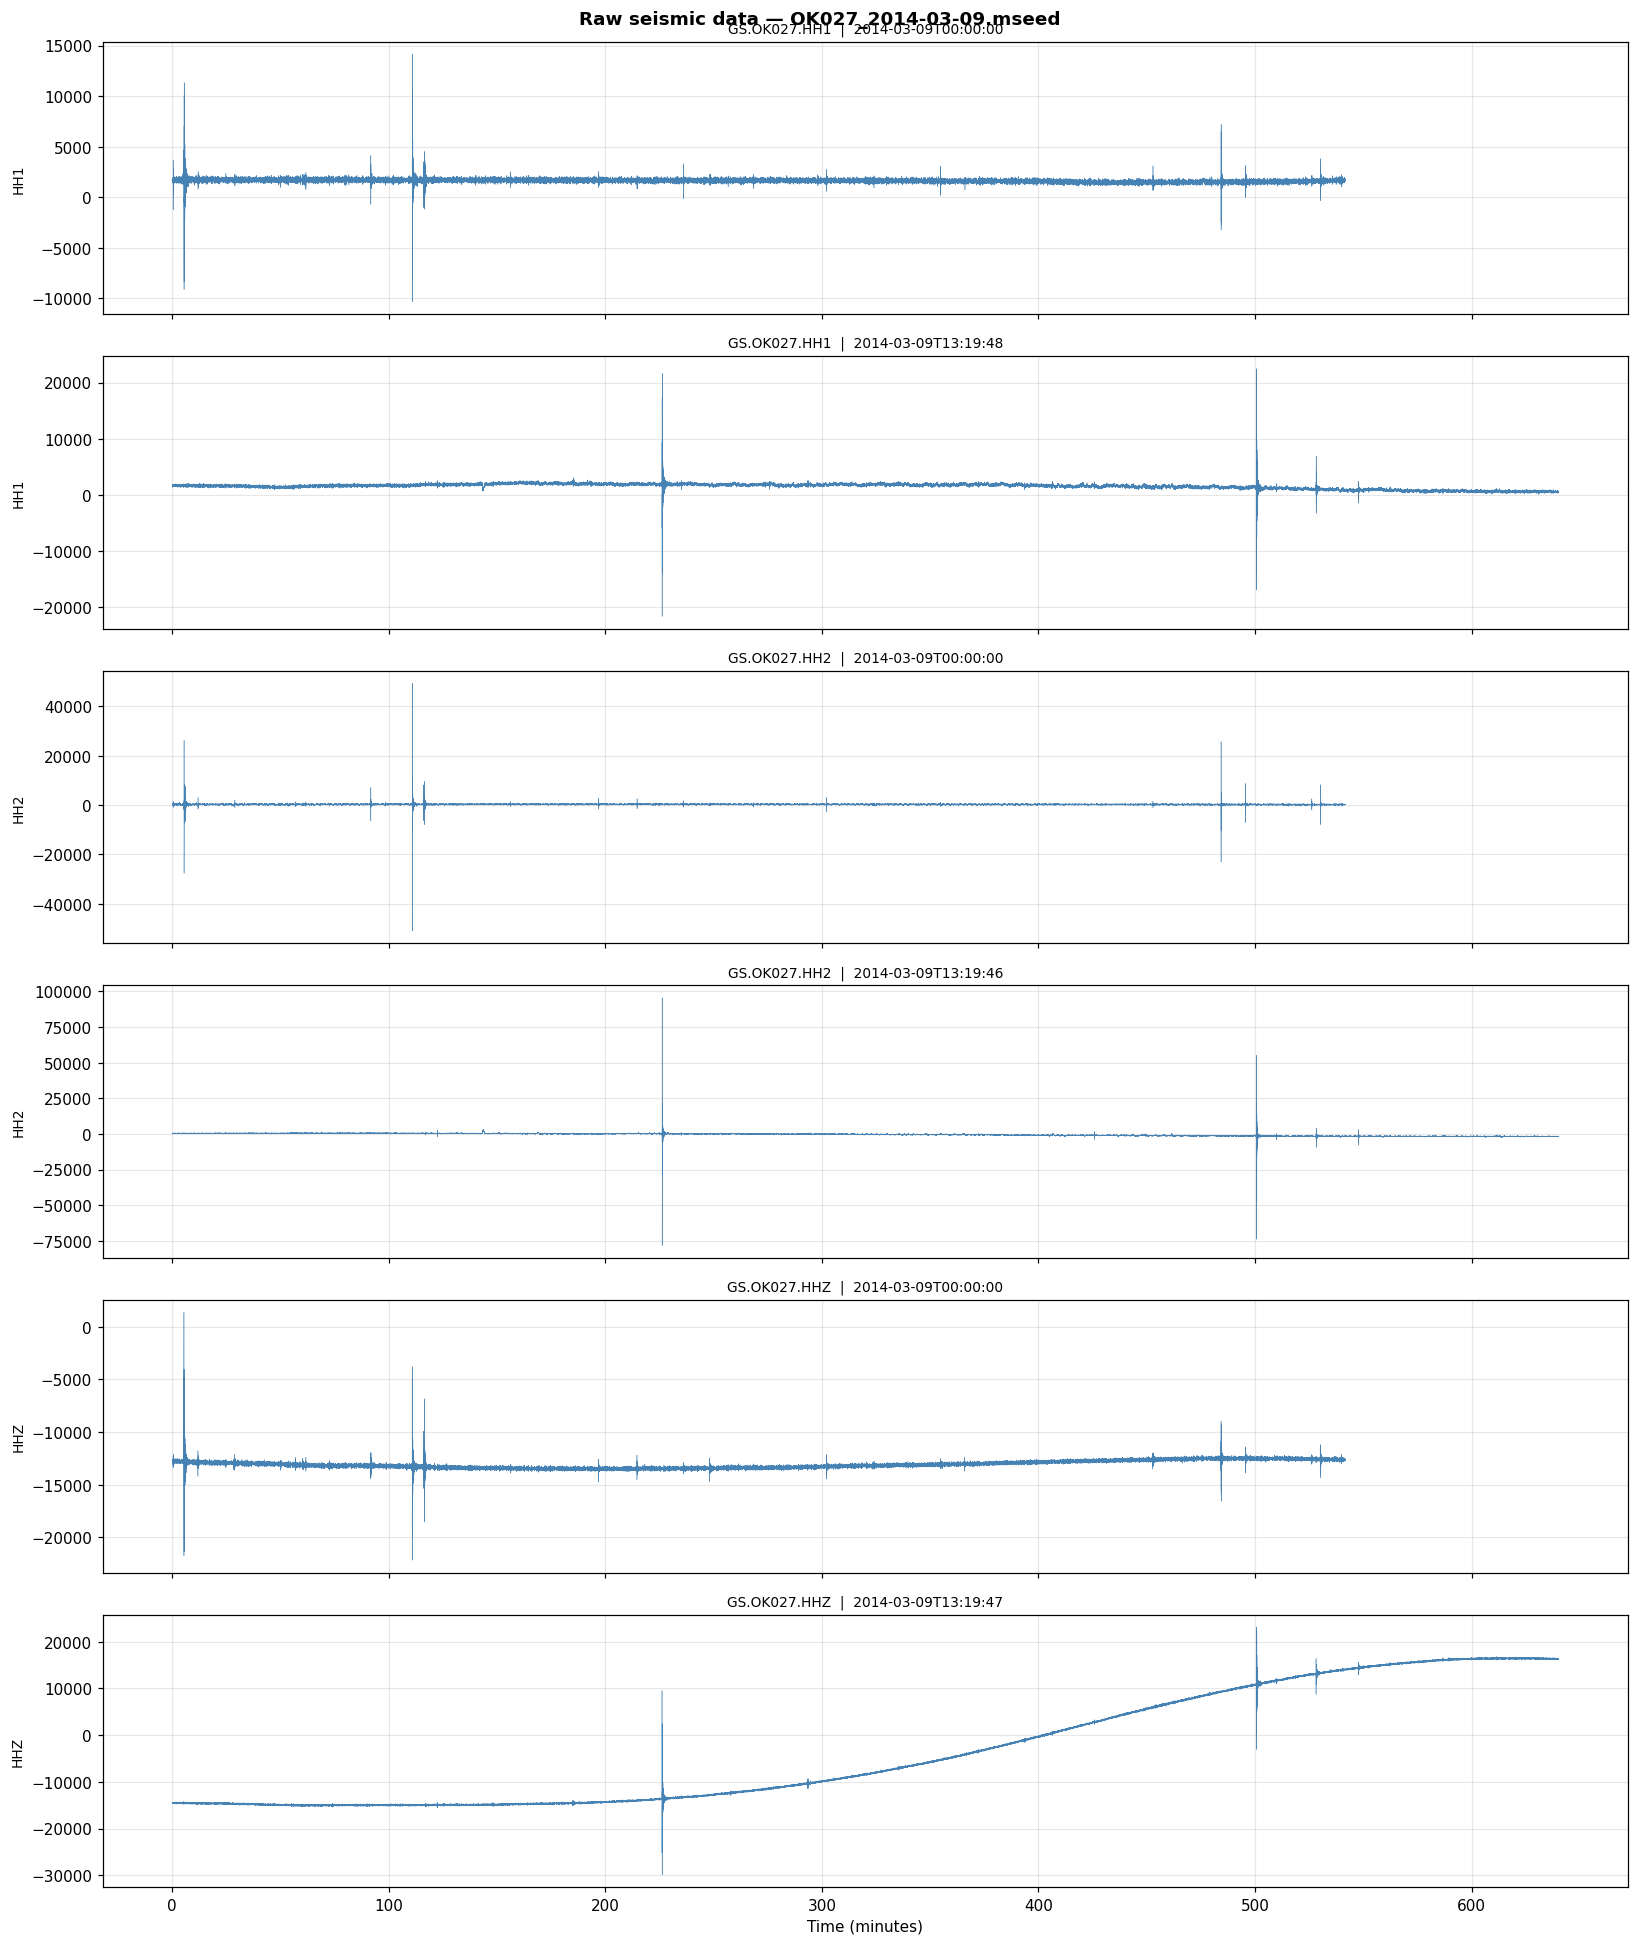

In [6]:
mseed_files = sorted(f for f in os.listdir(SEISMIC_DIR) if f.endswith('.mseed'))
fname = random.choice(mseed_files)
print(f'File: {fname}')

st = read(os.path.join(SEISMIC_DIR, fname))
print(st)

fig, axes = plt.subplots(len(st), 1, figsize=(15, 3 * len(st)), sharex=True)
if len(st) == 1:
    axes = [axes]

for ax, tr in zip(axes, st):
    t = np.arange(len(tr.data)) / tr.stats.sampling_rate / 60
    ax.plot(t, tr.data, lw=0.3, color='steelblue')
    ax.set_ylabel(tr.stats.channel, fontsize=9)
    ax.set_title(
        f'{tr.stats.network}.{tr.stats.station}.{tr.stats.channel}  |  '
        f'{str(tr.stats.starttime)[:19]}',
        fontsize=9
    )
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Time (minutes)')
fig.suptitle(f'Raw seismic data — {fname}', fontweight='bold')
plt.tight_layout()
plt.show()

## 2 — Effect of preprocessing

Steps applied in script 4: **normalize (global max) → detrend linear → demean**.  
First 5 minutes of the last trace shown for readability.

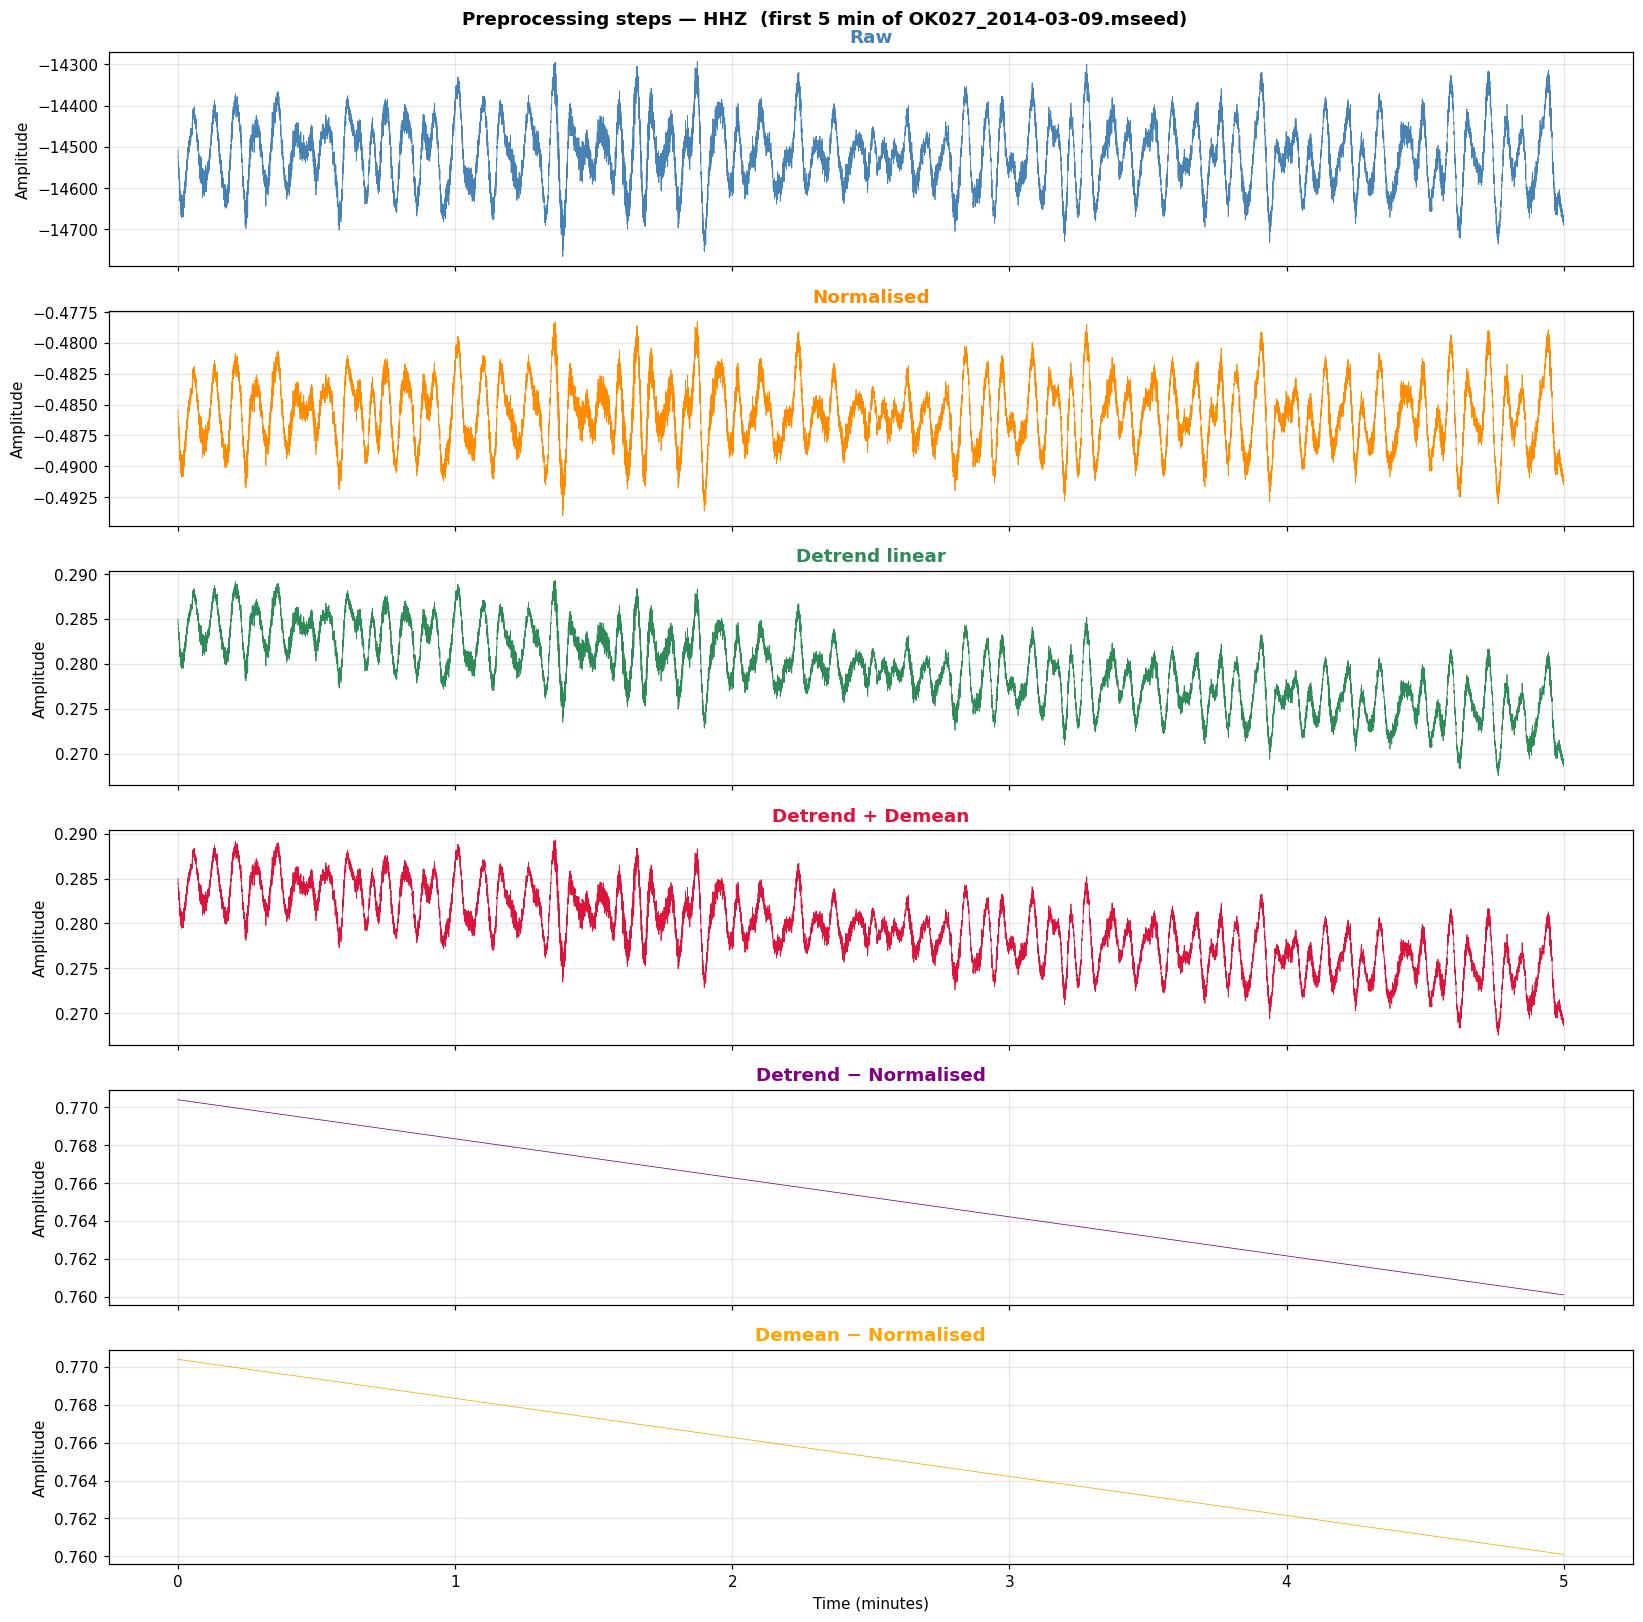

In [7]:
tr_raw = st[-1].copy()

tr_norm = tr_raw.copy()
tr_norm.normalize()

tr_detrend = tr_norm.copy()
tr_detrend.detrend('linear')

tr_demean = tr_detrend.copy()
tr_demean.detrend('demean')

tr_detrend_minus_norm = tr_norm.copy()
tr_detrend_minus_norm.data = tr_detrend.data - tr_norm.data

tr_demean_minus_norm = tr_norm.copy()
tr_demean_minus_norm.data = tr_demean.data - tr_norm.data

seg = int(5 * 60 * SAMPLING_RATE)

steps = [
    (tr_raw,                'Raw',                   'steelblue'),
    (tr_norm,               'Normalised',             'darkorange'),
    (tr_detrend,            'Detrend linear',         'seagreen'),
    (tr_demean,             'Detrend + Demean',       'crimson'),
    (tr_detrend_minus_norm, 'Detrend − Normalised',  'purple'),
    (tr_demean_minus_norm,  'Demean − Normalised',   'orange'),
]

fig, axes = plt.subplots(6, 1, figsize=(15, 15), sharex=True)

for ax, (tr, label, color) in zip(axes, steps):
    data  = tr.data[:seg]
    t_seg = np.arange(len(data)) / SAMPLING_RATE / 60
    ax.plot(t_seg, data, lw=0.5, color=color)
    ax.set_ylabel('Amplitude')
    ax.set_title(label, fontweight='bold', color=color)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Time (minutes)')
fig.suptitle(
    f'Preprocessing steps — {tr_raw.stats.channel}  (first 5 min of {fname})',
    fontweight='bold'
)
plt.tight_layout()
plt.show()

## 3 — Earthquake vs Noise 10-second windows

Earthquake windows (original): 756
Noise windows               : 62656


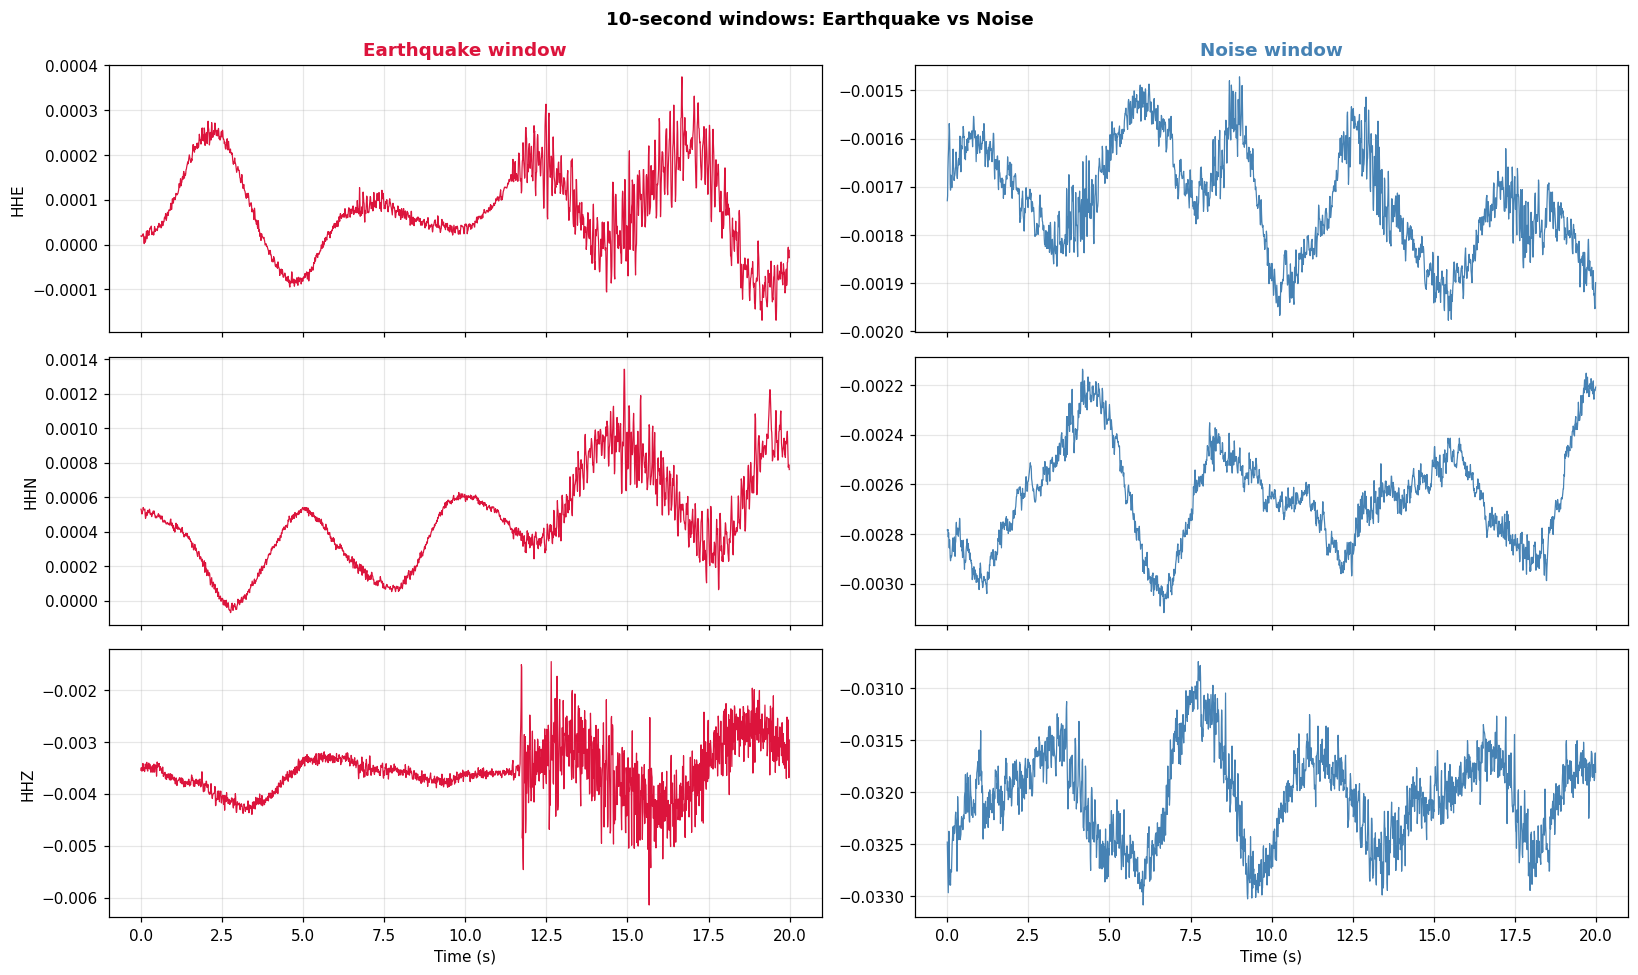

In [8]:
eq_originals = sorted(f for f in os.listdir(EQ_DIR)    if f.endswith('.csv') and '_aug' not in f)
noise_files  = sorted(f for f in os.listdir(NOISE_DIR) if f.endswith('.csv'))

print(f'Earthquake windows (original): {len(eq_originals)}')
print(f'Noise windows               : {len(noise_files)}')

if not eq_originals or not noise_files:
    print('No windowed files found — run scripts 3 and 4 first.')
else:
    eq_data    = ensure_2d(np.loadtxt(os.path.join(EQ_DIR,    random.choice(eq_originals)), delimiter=','))
    noise_data = ensure_2d(np.loadtxt(os.path.join(NOISE_DIR, random.choice(noise_files)),  delimiter=','))

    n_ch = min(eq_data.shape[0], noise_data.shape[0])
    t    = np.arange(eq_data.shape[1]) / SAMPLING_RATE
    ch_labels = ['HHE', 'HHN', 'HHZ'][:n_ch]

    fig, axes = plt.subplots(n_ch, 2, figsize=(15, 3 * n_ch), sharex=True)
    if n_ch == 1:
        axes = axes[np.newaxis, :]

    for ch in range(n_ch):
        axes[ch, 0].plot(t, eq_data[ch],    lw=0.8, color='crimson')
        axes[ch, 0].set_ylabel(ch_labels[ch])
        axes[ch, 0].grid(alpha=0.3)
        axes[ch, 1].plot(t, noise_data[ch], lw=0.8, color='steelblue')
        axes[ch, 1].grid(alpha=0.3)

    axes[0, 0].set_title('Earthquake window', fontweight='bold', color='crimson')
    axes[0, 1].set_title('Noise window',      fontweight='bold', color='steelblue')
    for ax in axes[-1]:
        ax.set_xlabel('Time (s)')

    fig.suptitle('10-second windows: Earthquake vs Noise', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 4 — Data Augmentation

One augmentation method is used: **Gaussian noise**.  
Bandpass filtering and time shifting are both excluded — bandpass re-normalisation can artificially amplify low-energy windows to resemble earthquakes, and time shifting does not produce visually convincing seismic waveform variations.

- **4a** — one original window + Gaussian noise applied once (overview)  
- **4b** — Gaussian noise: effect of increasing sigma

In [9]:
# Load one original earthquake window used for all augmentation plots
eq_originals = sorted(f for f in os.listdir(EQ_DIR) if f.endswith('.csv') and '_aug' not in f)

if not eq_originals:
    print('No earthquake files found — run scripts 3 and 4 first.')
else:
    orig_data  = ensure_2d(np.loadtxt(os.path.join(EQ_DIR, eq_originals[0]), delimiter=','))
    n_ch       = orig_data.shape[0]
    ch_labels  = ['HHE', 'HHN', 'HHZ'][:n_ch]
    print(f'Using: {eq_originals[0]}  shape={orig_data.shape}')

Using: 2014-02-15_00-19-00_2014-02-15_00-19-20.csv  shape=(3, 2000)


### 4a — Original + Gaussian noise applied once

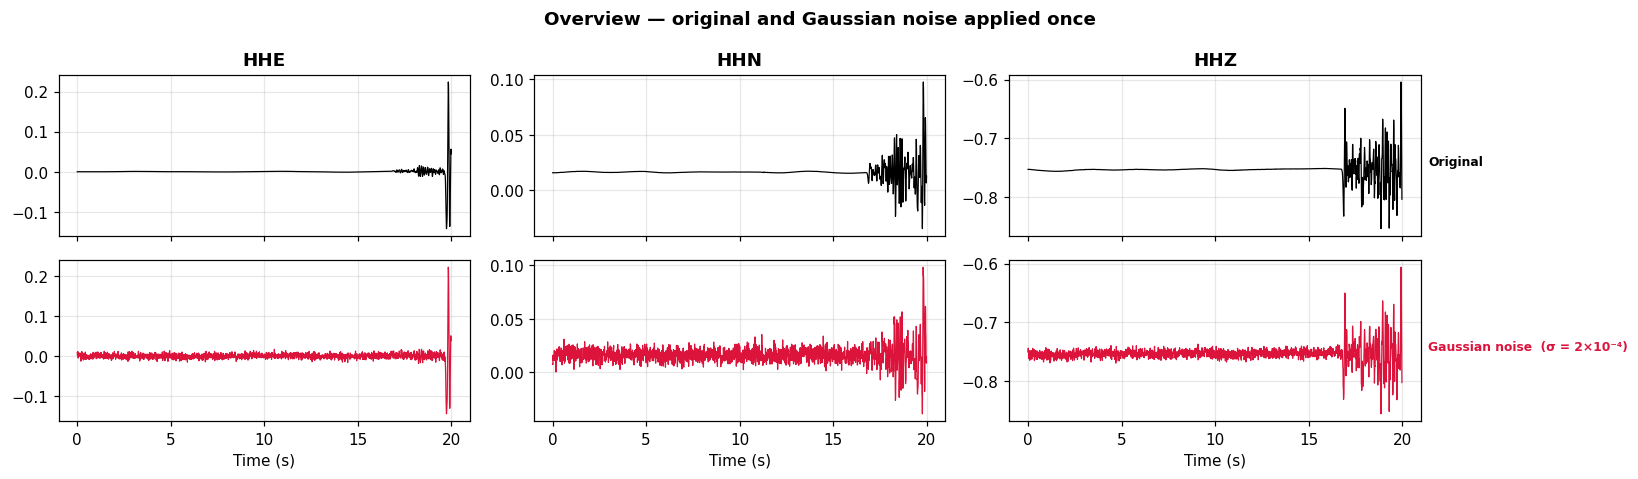

In [10]:
np.random.seed(0)  # reproducible examples

rows   = [orig_data,
          gauss(orig_data, sigma=50e-4)]
labels = ['Original',
          'Gaussian noise  (σ = 2×10⁻⁴)']
colors = ['black', 'crimson']

plot_progression(rows, labels, ch_labels,
                 'Overview — original and Gaussian noise applied once',
                 colors)

### 4b — Gaussian noise: increasing sigma

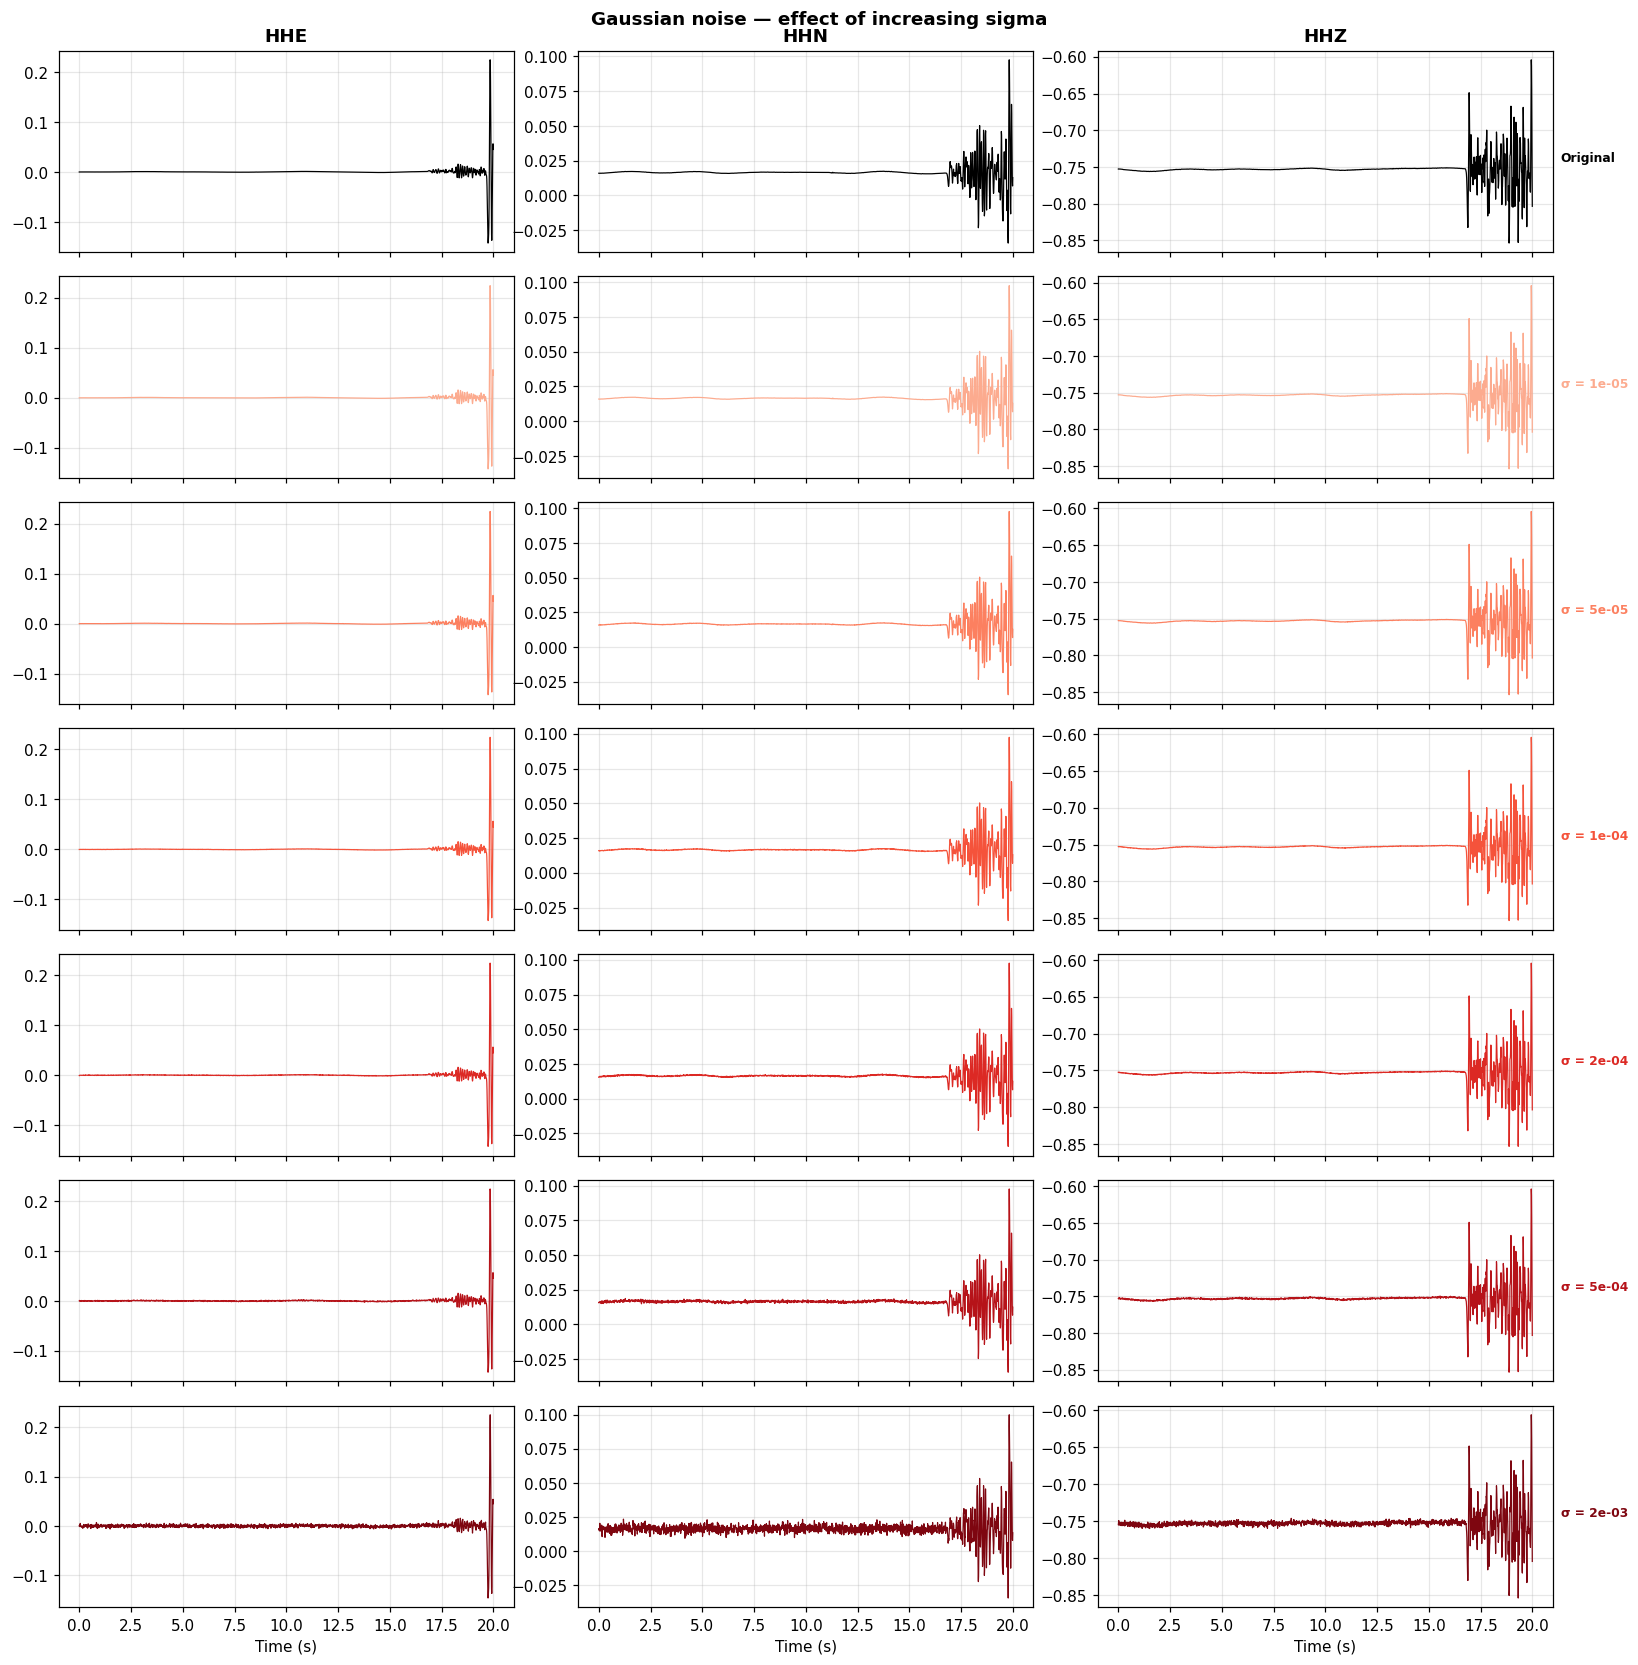

In [12]:
np.random.seed(1)

sigmas = [1e-5, 5e-5, 1e-4, 2e-4, 5e-4, 20e-4]

rows   = [orig_data] + [gauss(orig_data, sigma=s) for s in sigmas]
labels = ['Original'] + [f'σ = {s:.0e}' for s in sigmas]
colors = ['black'] + list(plt.cm.Reds(np.linspace(0.3, 0.95, len(sigmas))))

plot_progression(rows, labels, ch_labels,
                 'Gaussian noise — effect of increasing sigma',
                 colors)